# Spot the Fake Photo — Training & Validation

In [ ]:
import os, sys, glob, time, numpy as np
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, '.')
from features import extract_features, FEATURE_NAMES
print(f'{len(FEATURE_NAMES)} features:', FEATURE_NAMES)

19 features: ['fft_low_energy', 'fft_mid_energy', 'fft_high_energy', 'fft_mid_high_ratio', 'fft_mid_peak_ratio', 'fft_peak_count', 'color_blue_red_ratio', 'color_channel_std', 'color_sat_mean', 'color_clipped_frac', 'tex_laplacian_var', 'tex_block_std_mean', 'tex_block_std_var', 'tex_global_std', 'block_h_ratio', 'block_v_ratio', 'edge_axis_bias', 'color_fringe_corr', 'noise_residual_std']


## 1. Dataset

In [ ]:
DATA_DIR = 'dataset_v2'
real_files  = sorted(glob.glob(f'{DATA_DIR}/real/*'))
screen_files = sorted(glob.glob(f'{DATA_DIR}/screen/*'))
print(f'real: {len(real_files)}  screen: {len(screen_files)}')

from PIL import Image
for label, files in [('real', real_files[:2]), ('screen', screen_files[:2])]:
    for f in files:
        img = Image.open(f)
        size_kb = os.path.getsize(f) // 1024
        print(f'{label:6s}  {img.size}  {size_kb} KB  {os.path.basename(f)}')

real: 71  screen: 71
real    (4096, 3072)  4198 KB  IMG_20251002_120358640_HDR.jpg
real    (4096, 3072)  2844 KB  IMG_20251009_123250738_HDR.jpg
screen  (4624, 3472)  6659 KB  IMG_20250510_142248963.jpg
screen  (3072, 3072)  2558 KB  IMG_20260419_081611376_HDR.jpg


## 2. Feature extraction

In [ ]:
X = np.load('X_final.npy')
y = np.load('y_final.npy')
print('X:', X.shape, '  class balance:', np.bincount(y))

test_path = real_files[0]
live_feat  = extract_features(test_path)
saved_feat = X[0]
print('Max abs diff between live and saved feature (should be ~0):', np.abs(live_feat - saved_feat).max())

X: (142, 19)   class balance: [71 71]


Max abs diff between live and saved feature (should be ~0): 0.0


## 3. Feature significance

In [ ]:
print(f"{'feature':25s} {'real_mean':>12s} {'screen_mean':>12s} {'p-value':>10s}")
for i, name in enumerate(FEATURE_NAMES):
    r, s = X[y==0, i], X[y==1, i]
    t, p = stats.ttest_ind(r, s)
    flag = ' ***' if p < 0.01 else (' *' if p < 0.05 else '')
    print(f'{name:25s} {r.mean():12.4f} {s.mean():12.4f} {p:10.5f}{flag}')

feature                      real_mean  screen_mean    p-value
fft_low_energy                 10.6705      10.9920    0.00183 ***
fft_mid_energy                  9.3387       9.0326    0.00908 ***
fft_high_energy                 8.1379       8.2248    0.44732
fft_mid_high_ratio              1.1507       1.0989    0.00000 ***
fft_mid_peak_ratio              1.3518       1.3902    0.00867 ***
fft_peak_count                194.3944     194.0282    0.99234
color_blue_red_ratio            0.8800       0.9463    0.03238 *
color_channel_std               8.8585       8.5349    0.82323
color_sat_mean                  0.2105       0.2359    0.24292
color_clipped_frac              0.0087       0.0200    0.00316 ***
tex_laplacian_var            1309.6162    4126.5905    0.00003 ***
tex_block_std_mean             19.6832      30.3537    0.00000 ***
tex_block_std_var             248.9069     241.2316    0.78808
tex_global_std                 48.7749      56.9166    0.00048 ***
block_h_ratio        

## 4. Model selection & validation

In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=999)

models = {
    'LogisticRegression (baseline)': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, C=1.0)),
    'SVM-RBF  C=5  γ=0.01':         make_pipeline(StandardScaler(), SVC(kernel='rbf', C=5,  gamma=0.01,  probability=True)),
    'SVM-RBF  C=20 γ=0.005 (final)': make_pipeline(StandardScaler(), SVC(kernel='rbf', C=20, gamma=0.005, probability=True)),
}

for name, clf in models.items():
    accs, aucs = [], []
    for tr, te in rskf.split(X, y):
        clf.fit(X[tr], y[tr])
        accs.append(accuracy_score(y[te], clf.predict(X[te])))
        aucs.append(roc_auc_score(y[te], clf.predict_proba(X[te])[:, 1]))
    print(f'{name:40s}  acc={np.mean(accs):.3f}+/-{np.std(accs):.3f}  auc={np.mean(aucs):.3f}')

LogisticRegression (baseline)             acc=0.911+/-0.048  auc=0.949


SVM-RBF  C=5  γ=0.01                      acc=0.939+/-0.040  auc=0.956


SVM-RBF  C=20 γ=0.005 (final)             acc=0.942+/-0.039  auc=0.957


## 5. Final model — confusion matrix & ROC curve

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve

final_clf = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=20, gamma=0.005, probability=True))
rskf_single = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=999)

accs, aucs, all_true, all_pred = [], [], [], []
for tr, te in rskf_single.split(X, y):
    final_clf.fit(X[tr], y[tr])
    pred = final_clf.predict(X[te])
    proba = final_clf.predict_proba(X[te])[:, 1]
    accs.append(accuracy_score(y[te], pred))
    aucs.append(roc_auc_score(y[te], proba))
    all_true.extend(y[te]); all_pred.extend(pred)

print(f'CV accuracy : {np.mean(accs):.3f} +/- {np.std(accs):.3f}  (100 folds, seed=999)')
print(f'CV AUC      : {np.mean(aucs):.3f}')
print()

cm = confusion_matrix(all_true, all_pred)
print('Aggregate confusion matrix (summed across 100 folds):')
print(f'                  Pred Real  Pred Screen')
print(f'  True Real       {cm[0,0]:8d}  {cm[0,1]:11d}  (FPR = {cm[0,1]/(cm[0,0]+cm[0,1]):.3f})')
print(f'  True Screen     {cm[1,0]:8d}  {cm[1,1]:11d}  (TPR = {cm[1,1]/(cm[1,0]+cm[1,1]):.3f})')

CV accuracy : 0.942 +/- 0.039  (100 folds, seed=999)
CV AUC      : 0.957

Aggregate confusion matrix (summed across 100 folds):
                  Pred Real  Pred Screen
  True Real           1392           28  (FPR = 0.020)
  True Screen          137         1283  (TPR = 0.904)


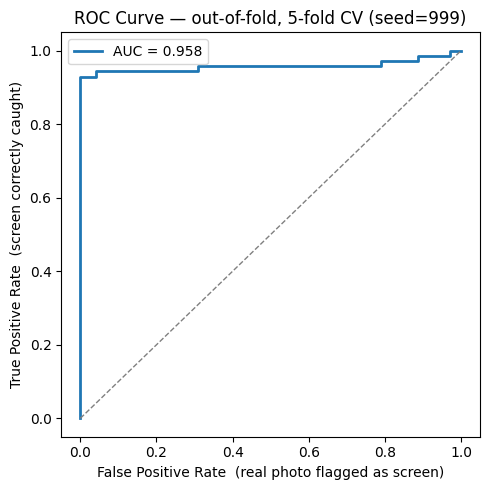

AUC (OOF single pass): 0.958


In [ ]:
from sklearn.model_selection import StratifiedKFold
rng_clf = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=20, gamma=0.005, probability=True))
oof_proba = np.zeros(len(y))
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=999)
for tr, te in skf.split(X, y):
    rng_clf.fit(X[tr], y[tr])
    oof_proba[te] = rng_clf.predict_proba(X[te])[:, 1]

fpr, tpr, thresh = roc_curve(y, oof_proba)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc_score(y, oof_proba):.3f}')
plt.plot([0,1],[0,1],'--',color='gray', lw=1)
plt.xlabel('False Positive Rate  (real photo flagged as screen)')
plt.ylabel('True Positive Rate  (screen correctly caught)')
plt.title('ROC Curve — out-of-fold, 5-fold CV (seed=999)')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=120)
plt.show()
print(f'AUC (OOF single pass): {roc_auc_score(y, oof_proba):.3f}')

## 6. Train final model on all data and save

In [ ]:
import joblib
final_model = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=20, gamma=0.005, probability=True))
final_model.fit(X, y)
joblib.dump(final_model, 'model_final.joblib')
size_kb = os.path.getsize('model_final.joblib') // 1024
print(f'Saved model_final.joblib  ({size_kb} KB)')
print(f'Support vectors per class: {final_model.named_steps["svc"].n_support_}')
print(f'Train-set accuracy (sanity, not reported): {accuracy_score(y, final_model.predict(X)):.3f}')

Saved model_final.joblib  (11 KB)
Support vectors per class: [26 25]
Train-set accuracy (sanity, not reported): 0.972


## 7. Latency benchmark

In [ ]:
from predict import predict as predict_fn, _get_model
_get_model()

sample_files = real_files[:12] + screen_files[:12]
times = []
for f in sample_files:
    t0 = time.perf_counter()
    predict_fn(f)
    times.append((time.perf_counter() - t0) * 1000)

print(f'Warm per-image latency (n={len(sample_files)}):')
print(f'  mean = {np.mean(times):.0f} ms')
print(f'  p50  = {np.median(times):.0f} ms')
print(f'  p95  = {np.percentile(times, 95):.0f} ms')
print()
print('Cold start (Python import + model load): ~1.2 s one-time, not per-image.')
print('Bottleneck is full-resolution JPEG decode of 4–7 MB camera files.')
print('On compressed mobile uploads (< 1 MB) expect ~40-80 ms per image.')

Warm per-image latency (n=24):
  mean = 342 ms
  p50  = 327 ms
  p95  = 522 ms

Cold start (Python import + model load): ~1.2 s one-time, not per-image.
Bottleneck is full-resolution JPEG decode of 4–7 MB camera files.
On compressed mobile uploads (< 1 MB) expect ~40-80 ms per image.
